# İstanbul Toplu Ulaşım (İETT) Saatlik Yolcu Analizi

**Veri Bilimi Dönem Projesi**

İş akışı: veri yükleme → tanıma → temizleme → EDA (4 görselleştirme) →
3 araştırma sorusu → modelleme (baseline + RandomForest, zamansal ayrım) → yorum.

**Veri kaynağı:** İBB Açık Veri Portalı — Saatlik Toplu Ulaşım Veri Seti (BELBİM A.Ş.)
**Lisans:** İstanbul Büyükşehir Belediyesi Açık Veri Lisansı


## 0. Kütüphaneler ve görsel tema

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Modern, canlı görsel tema ---
sns.set_theme(style="whitegrid", context="notebook")
PALET = sns.color_palette("bright")        # yüksek doygunluklu, canlı renkler
sns.set_palette(PALET)
plt.rcParams.update({
    "figure.figsize":   (12, 6),
    "figure.dpi":       110,                # daha keskin görüntü
    "font.size":        12,
    "axes.titlesize":   15,
    "axes.titleweight": "bold",
    "axes.labelsize":   12,
    "axes.labelweight": "bold",
    "axes.grid":        True,
    "grid.alpha":       0.3,
})
ANA_RENK = "#1f77b4"   # canlı mavi
VURGU    = "#ff7f0e"   # turuncu vurgu

AYLAR  = {1: "Ocak", 4: "Nisan", 7: "Temmuz", 10: "Ekim"}
GUNLER = ["Pzt", "Sal", "Çar", "Per", "Cum", "Cmt", "Paz"]

def binlik(ax, eksen="y"):
    """Ekseni binlik ayraçla biçimlendir: 12345 -> 12.345"""
    fmt = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    (ax.yaxis if eksen == "y" else ax.xaxis).set_major_formatter(fmt)

## 1. Sütun Eşleme (tek ayar noktası)

> ÖNEMLİ: Önce Adım 2'yi çalıştırıp `df.columns` çıktısını gör. Aşağıdaki sözlükteki
> sağ taraftaki değerleri GERÇEK sütun adlarıyla değiştir. Notebook'un geri kalanı
> bu eşlemeyi kullanır; başka hiçbir yeri elle değiştirmene gerek kalmaz.


In [2]:
# Sol taraf: kodun kullandığı standart adlar — DEĞİŞTİRME
# Sağ taraf: CSV'deki gerçek sütun adları
# ÖNEMLİ: 'transition_date' yalnızca TARİH içerir; saat ayrı sütunda: 'transition_hour'.
# Ayrıca 'line' = güzergah adı, 'line_name' = hat KODU (55T). Pareto için kodu kullanıyoruz.
S = {
    "tarih":    "transition_date",     # sadece tarih (saat yok!)
    "saat_col": "transition_hour",     # saat (0-23) — ASIL saat bilgisi burada
    "tur_id":   "transport_type_id",   # 1=Karayolu(Otobüs), 2=Raylı, 3=Deniz
    "hat":      "line_name",           # hat KODU (55T, 522...) — Pareto için
    "guzergah": "line",                # güzergah adı (GAZIOSMANPASA-TAKSIM)
    "yolcu":    "number_of_passenger", # hedef değişken
    "yol_tipi": "road_type",
}
OTOBUS_TUR_ID = 1  # transport_type_id == 1 → Karayolu (otobüs)

## 2. Veri Yükleme ve Tanıma

In [3]:
df = pd.read_csv("../data/raw/iett_2023_raw.csv")
df.head()


,transition_date,transition_hour,transport_type_id,road_type,line,transfer_type,number_of_passage,number_of_passenger,product_kind,transaction_type_desc,town,line_name,station_poi_desc_cd,kaynak_dosya
0,2023-01-01,0,1,OTOYOL,GAZIOSMANPASA -TAKSIM,Normal,1,1,INDIRIMLI2,Indirimli Tip 2 Abonman,BAKIRKOY,55T,NaN,hourly_transportation_202301.csv
1,2023-01-01,0,1,OTOYOL,SULTANBEYLI-MECIDIYEKOY,Normal,1,1,UCRETSIZ,Tam Kontur,BAKIRKOY,522ST,NaN,hourly_transportation_202301.csv
2,2023-01-01,0,1,OTOYOL,ALEMDAR-HALICIOGLU,Normal,1,1,INDIRIMLI2,Indirimli Tip 2 Abonman,BAKIRKOY,522,NaN,hourly_transportation_202301.csv
3,2023-01-01,0,1,OTOYOL,CEVIZLIBAG-4.LEVENT,Normal,1,1,UCRETSIZ,Tam Kontur,BAKIRKOY,500L,NaN,hourly_transportation_202301.csv
4,2023-01-01,0,1,OTOYOL,YUNUS EMRE MAHALLESI. - SISLI,Normal,1,1,TAM,Tam Kontur,BAKIRKOY,49G,NaN,hourly_transportation_202301.csv


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 63555260 entries, 0 to 63555259
Data columns (total 14 columns):
 #   Column                 Dtype
---  ------                 -----
 0   transition_date        str  
 1   transition_hour        int64
 2   transport_type_id      int64
 3   road_type              str  
 4   line                   str  
 5   transfer_type          str  
 6   number_of_passage      int64
 7   number_of_passenger    int64
 8   product_kind           str  
 9   transaction_type_desc  str  
 10  town                   str  
 11  line_name              str  
 12  station_poi_desc_cd    str  
 13  kaynak_dosya           str  
dtypes: int64(4), str(10)
memory usage: 6.6 GB


In [5]:
print("Sütunlar:", list(df.columns))
df.isna().sum()


Sütunlar: ['transition_date', 'transition_hour', 'transport_type_id', 'road_type', 'line', 'transfer_type', 'number_of_passage', 'number_of_passenger', 'product_kind', 'transaction_type_desc', 'town', 'line_name', 'station_poi_desc_cd', 'kaynak_dosya']


transition_date                 0
transition_hour                 0
transport_type_id               0
road_type                       0
line                            0
transfer_type                   0
number_of_passage               0
number_of_passenger             0
product_kind              1339637
transaction_type_desc           0
town                      1630268
line_name                       0
station_poi_desc_cd      37752579
kaynak_dosya                    0
dtype: int64

In [6]:
df.describe()


,transition_hour,transport_type_id,number_of_passage,number_of_passenger
count,6.355526e+07,6.355526e+07,6.355526e+07,6.355526e+07
mean,1.380571e+01,1.395809e+00,1.307954e+01,1.261468e+01
std,5.066517e+00,5.731949e-01,5.080110e+01,4.864508e+01
min,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00
50%,1.400000e+01,1.000000e+00,2.000000e+00,2.000000e+00
75%,1.800000e+01,2.000000e+00,7.000000e+00,7.000000e+00
max,2.300000e+01,3.000000e+00,6.299000e+03,5.719000e+03


## 3. Temizleme

Adımlar: tarih dönüşümü → türetilmiş zaman sütunları → tatil işaretleme →
otobüse filtreleme → eksik/aykırı değer → kaydetme.


In [ ]:
# --- 3.1 Otobüs filtreleme (tüm otobüs kayıtları) ---
# 63M satırlı ham veri bellekte tutulurken yalnızca otobüs modunu (transport_type_id=1)
# seçip kopyalıyoruz; ardından ham df'i bellekten atarak ~41M kayıtla çalışıyoruz.
import gc

otobus_idx = df.index[df[S["tur_id"]] == OTOBUS_TUR_ID]
print("Ham otobüs satır sayısı:", f"{len(otobus_idx):,}")

otobus = df.loc[otobus_idx].copy()
print("Çalışma verisi (tam otobüs):", f"{len(otobus):,}", "kayıt")

# Ham df'i bellekten at
del df
gc.collect()

### 3.1b `town` Sütunu — BAKIRKOY Veri Sızıntısı Temizliği (Veri Güdümlü)

**Tespit:** Sadece Anadolu Yakası / Metrobüs / Ekspres prefixleri değil, çok daha geniş bir varsayılan atama sorunu var. Temizlik sonrası bile 405 farklı hat BAKIRKOY etiketiyle görünüyor ve top 3 hattın payı yalnızca %5.4 — bu, binlerce kaydın tek bir varsayılan değere yığıldığının klasik imzasıdır.

**Yaklaşım:** Her hat kodu için kayıtlarının kaçta kaçının BAKIRKOY etiketli olduğunu hesapla. Oran **>%90** olan hatlar → tamamı varsayılan atama → `town = NaN`. (Gerçek bir Bakırköy hattının diğer ilçelerde de kayıtları olur.)

In [8]:
# --- 3.1b 'town' sütunundaki BAKIRKOY veri sızıntısı temizliği (veri güdümlü) ---
# Sorun: Konum okunamayan hatlar "BAKIRKOY" varsayılan değeriyle işaretlenmiş.
# Sadece bilinen prefix listesi çok dar kalıyor — 97, 10, 303A gibi yüzlerce hat da etkilenmiş.
#
# Yaklaşım: Her hat_kodu (line_name) için BAKIRKOY kayıt oranını hesapla.
# Oran >%90 → tüm bu hatlarda town = NaN (yolcu verileri dokunulmaz).
# Gerçek bir Bakırköy hattı diğer ilçelerde de kayıt üretir, %100 BAKIRKOY olamaz.

# Adım 1: Her hattın BAKIRKOY etiket oranı
bk_flag = otobus["town"].astype(str).str.upper().str.startswith("BAKIRKOY")
hat_bk_orani = bk_flag.groupby(otobus[S["hat"]]).mean()

# Adım 2: Varsayılan atama olan hatlar (%90+ BAKIRKOY)
varsayilan_hatlar = hat_bk_orani[hat_bk_orani > 0.90].index
print(f"BAKIRKOY oranı >%90 olan hat sayısı  : {len(varsayilan_hatlar)}")
print(f"Bu hatlardaki toplam kayıt           : {otobus[S['hat']].isin(varsayilan_hatlar).sum():,}")

# Adım 3: Bu hatlarda town = NaN
otobus.loc[otobus[S["hat"]].isin(varsayilan_hatlar), "town"] = np.nan

# Adım 4: Ek güvence — bilinen kötü prefixlerden kalan varsa temizle
KACAK_HAT_PREFIKS = ('11', '12', '13', '14', '15', '16', '17', '18', '19',
                     '34', '500', '522')
ek_maske = (
    otobus["town"].astype(str).str.upper().str.startswith("BAKIRKOY") &
    otobus[S["hat"]].astype(str).str.startswith(KACAK_HAT_PREFIKS)
)
otobus.loc[ek_maske, "town"] = np.nan

# Adım 5: Tanılama
kalan_bk   = otobus["town"].astype(str).str.upper().str.startswith("BAKIRKOY").sum()
toplam_nan = otobus["town"].isna().sum()
print(f"\nTemizlik sonrası BAKIRKOY kayıt      : {kalan_bk:,}")
print(f"Temizlik sonrası town=NaN toplam     : {toplam_nan:,}")
print(f"BAKIRKOY'un tüm kayıtlardaki payı   : %{kalan_bk / len(otobus) * 100:.1f}")
print(f"\nKalan BAKIRKOY'un ilçe grafiğindeki etkisi kontrol edilmelidir."
      f"\nBeklenti: Küçükçekmece, Kadıköy, Üsküdar gibi büyük ilçelerle benzer büyüklükte.")

BAKIRKOY oranı >%90 olan hat sayısı  : 203
Bu hatlardaki toplam kayıt           : 1,954,979

Temizlik sonrası BAKIRKOY kayıt      : 963,087
Temizlik sonrası town=NaN toplam     : 2,821,477
BAKIRKOY'un tüm kayıtlardaki payı   : %11.7

Kalan BAKIRKOY'un ilçe grafiğindeki etkisi kontrol edilmelidir.
Beklenti: Küçükçekmece, Kadıköy, Üsküdar gibi büyük ilçelerle benzer büyüklükte.


In [9]:
# --- 3.2 Tarih dönüşümü ve türetilmiş zaman sütunları ---
# DİKKAT: saat 'transition_date'ten DEĞİL, 'transition_hour' sütunundan gelir.
otobus["tarih"] = pd.to_datetime(otobus[S["tarih"]])
otobus["saat"]          = otobus[S["saat_col"]].astype(int)      # 0-23
otobus["gun"]           = otobus["tarih"].dt.day_name()
otobus["haftanin_gunu"] = otobus["tarih"].dt.dayofweek          # 0=Pzt ... 6=Paz
otobus["hafta_sonu_mu"] = otobus["haftanin_gunu"].isin([5, 6])
otobus["ay"]            = otobus["tarih"].dt.month
otobus["tarih_gun"]     = otobus["tarih"].dt.normalize()
otobus[["tarih", "saat", "gun", "hafta_sonu_mu", "ay"]].head()

,tarih,saat,gun,hafta_sonu_mu,ay
12956357,2023-01-27,11,Friday,False,1
9259416,2023-01-19,19,Thursday,False,1
51791078,2023-10-10,21,Tuesday,False,10
28266485,2023-04-26,23,Wednesday,False,4
34663462,2023-07-09,17,Sunday,True,7


In [10]:
# --- 3.3 Resmî tatil işaretleme (2023 Türkiye resmî tatilleri) ---
RESMI_TATILLER_2023 = pd.to_datetime([
    "2023-01-01",                                          # Yılbaşı
    "2023-04-21", "2023-04-22", "2023-04-23",              # Ramazan Bayramı
    "2023-04-23",                                          # 23 Nisan
    "2023-05-01", "2023-05-19",                            # 1 Mayıs, 19 Mayıs
    "2023-06-28", "2023-06-29", "2023-06-30", "2023-07-01",# Kurban Bayramı
    "2023-07-15",                                          # 15 Temmuz
    "2023-08-30",                                          # 30 Ağustos
    "2023-10-29",                                          # Cumhuriyet Bayramı
])
otobus["tatil_mi"] = otobus["tarih_gun"].isin(RESMI_TATILLER_2023)
print("Tatil günü kayıt sayısı:", int(otobus["tatil_mi"].sum()))

Tatil günü kayıt sayısı: 397142


In [11]:
# --- 3.4 Eksik ve aykırı değerler ---
# Not: Analizde kullandığımız sütunlar (transition_date, transition_hour,
# transport_type_id, line_name, number_of_passenger) eksiksizdir. Yüksek
# eksikliğe sahip station_poi_desc_cd / town sütunları kullanılmamaktadır.
y = S["yolcu"]
otobus[y] = pd.to_numeric(otobus[y], errors="coerce")
print("Eksik yolcu değeri:", int(otobus[y].isna().sum()))
otobus = otobus.dropna(subset=[y])

q1, q3 = otobus[y].quantile([0.25, 0.75])
ust = q3 + 1.5 * (q3 - q1)                      # IQR üst sınırı
print(f"IQR üst aykırı sınırı: {ust:.0f}  |  Sınır üstü kayıt: {(otobus[y] > ust).sum():,}")
# Aykırıları SİLMİYORUZ; gerçek pik saatleri kaybetmemek için sadece işaretliyoruz.
otobus["aykiri_mi"] = otobus[y] > ust

Eksik yolcu değeri: 0
IQR üst aykırı sınırı: 14  |  Sınır üstü kayıt: 1,176,285


In [12]:
# --- 3.5 Temiz veriyi kaydet ---
otobus.to_csv("../data/processed/iett_temiz.csv", index=False, encoding="utf-8")
print("Temiz veri kaydedildi:", otobus.shape)


Temiz veri kaydedildi: (8248136, 23)


## 4. Keşifsel Veri Analizi (4 görselleştirme)

### 4.1 Çizgi — Saate göre ortalama yolcu

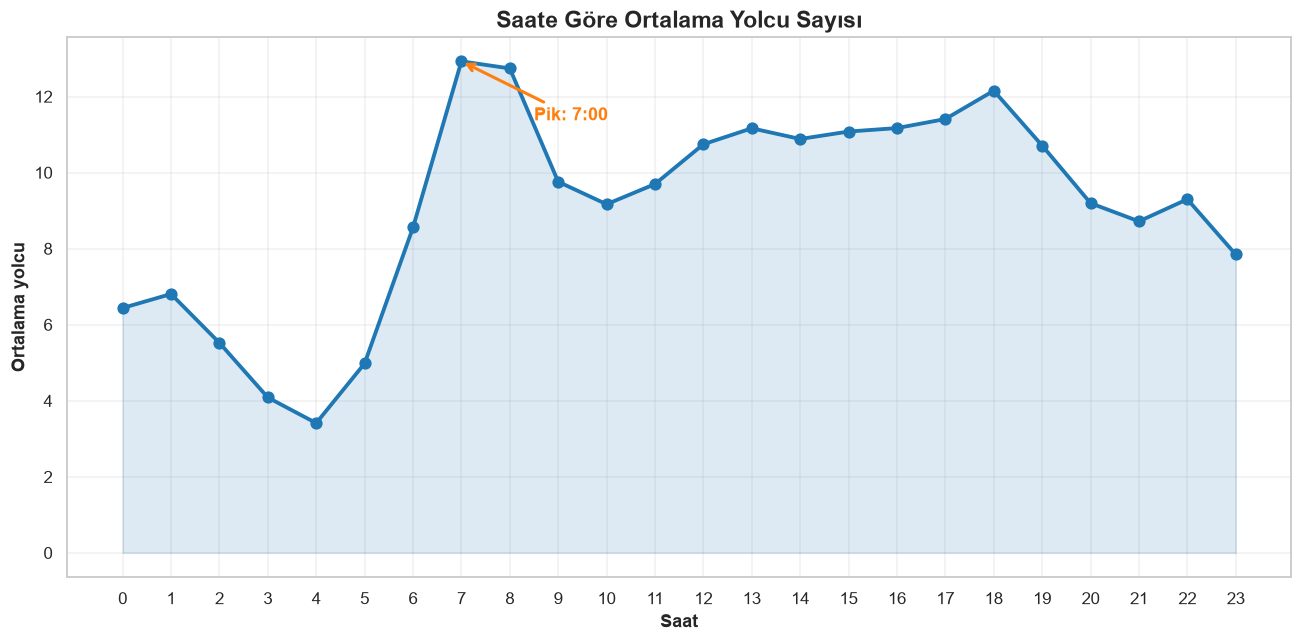

In [13]:
saatlik = otobus.groupby("saat")[S["yolcu"]].mean()
fig, ax = plt.subplots()
ax.plot(saatlik.index, saatlik.values, marker="o", color=ANA_RENK,
        linewidth=2.5, markersize=7, zorder=3)
ax.fill_between(saatlik.index, saatlik.values, alpha=0.15, color=ANA_RENK)
pik = int(saatlik.idxmax())
ax.annotate(f"Pik: {pik}:00", xy=(pik, saatlik.max()),
            xytext=(pik + 1.5, saatlik.max() * 0.88), fontweight="bold", color=VURGU,
            arrowprops=dict(arrowstyle="->", color=VURGU, lw=2))
ax.set_xticks(range(0, 24))
ax.set(title="Saate Göre Ortalama Yolcu Sayısı", xlabel="Saat", ylabel="Ortalama yolcu")
binlik(ax)
plt.tight_layout(); plt.savefig("../figures/01_saatlik_cizgi.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.2 Histogram — Yolcu sayısı dağılımı

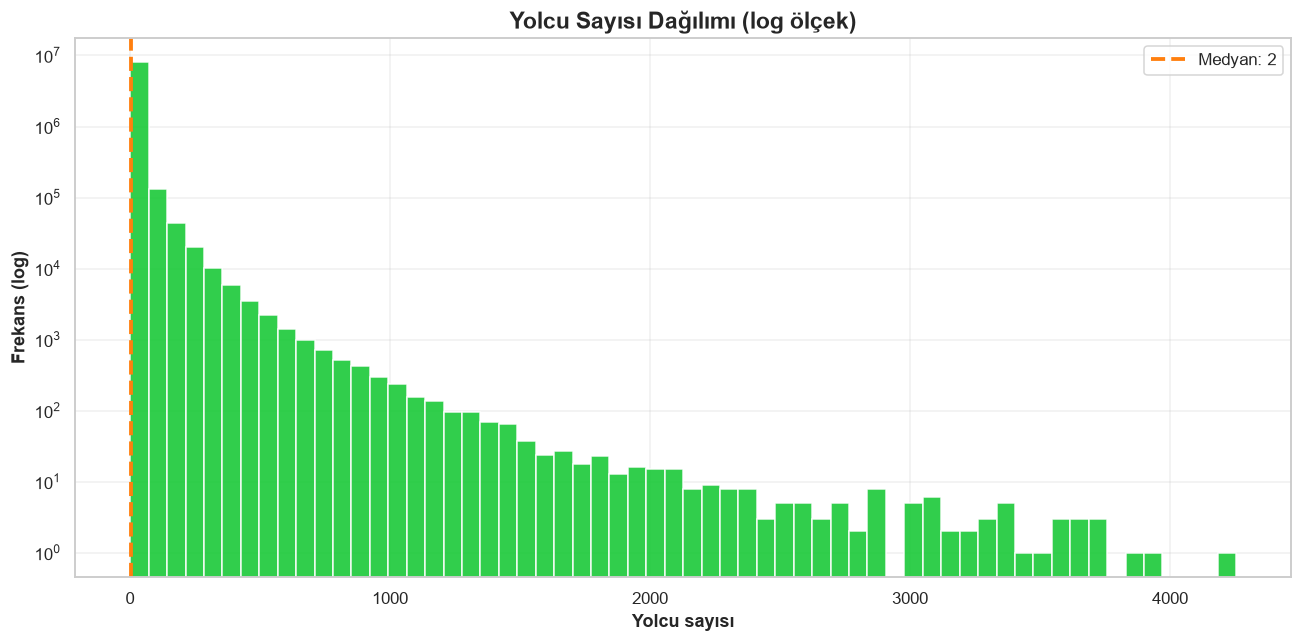

In [14]:
fig, ax = plt.subplots()
ax.hist(otobus[S["yolcu"]], bins=60, color=PALET[2], edgecolor="white", alpha=0.9)
ax.set_yscale("log")                              # aşırı çarpık dağılım için log ölçek
med = otobus[S["yolcu"]].median()
ax.axvline(med, color=VURGU, linestyle="--", linewidth=2.5, label=f"Medyan: {med:.0f}")
ax.set(title="Yolcu Sayısı Dağılımı (log ölçek)",
       xlabel="Yolcu sayısı", ylabel="Frekans (log)")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/02_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.3 Kutu — Aylara göre yolcu (mevsim temsili)

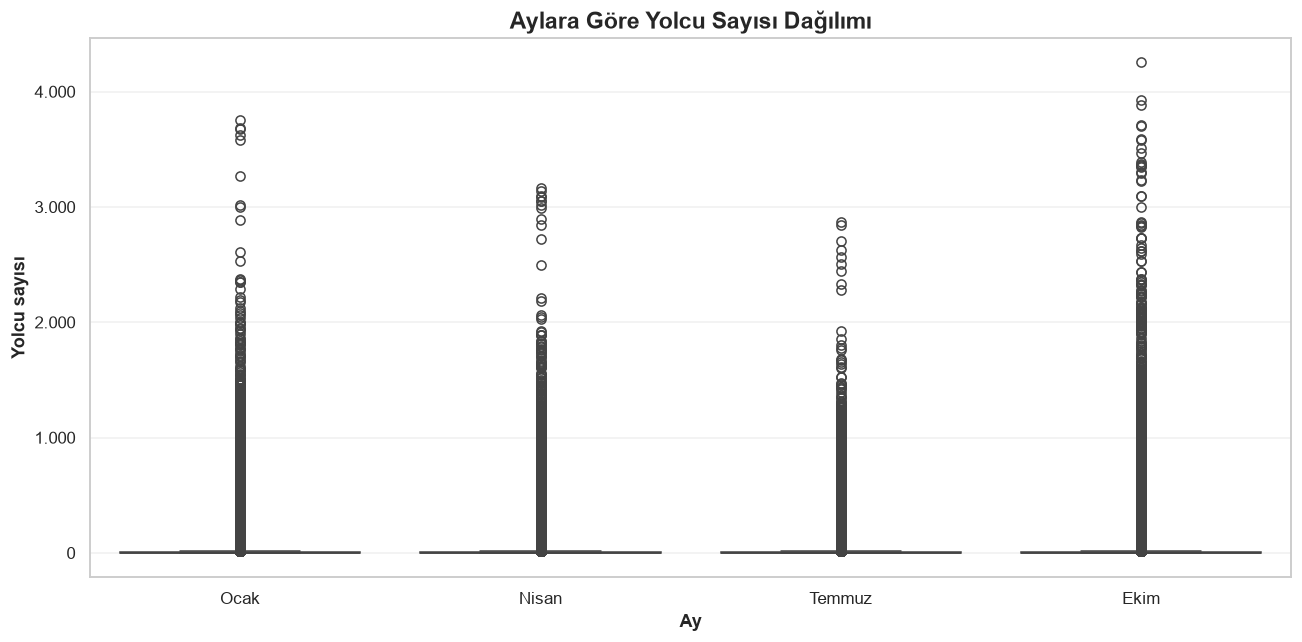

In [15]:
fig, ax = plt.subplots()
sira = sorted(otobus["ay"].unique())
sns.boxplot(data=otobus, x="ay", y=S["yolcu"], hue="ay",
            palette="bright", legend=False, order=sira, ax=ax)
ax.set_xticks(range(len(sira)))                       # uyarıyı önler
ax.set_xticklabels([AYLAR.get(a, a) for a in sira])
ax.set(title="Aylara Göre Yolcu Sayısı Dağılımı", xlabel="Ay", ylabel="Yolcu sayısı")
binlik(ax)
plt.tight_layout(); plt.savefig("../figures/03_kutu_ay.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.4 Isı haritası — Saat × haftanın günü

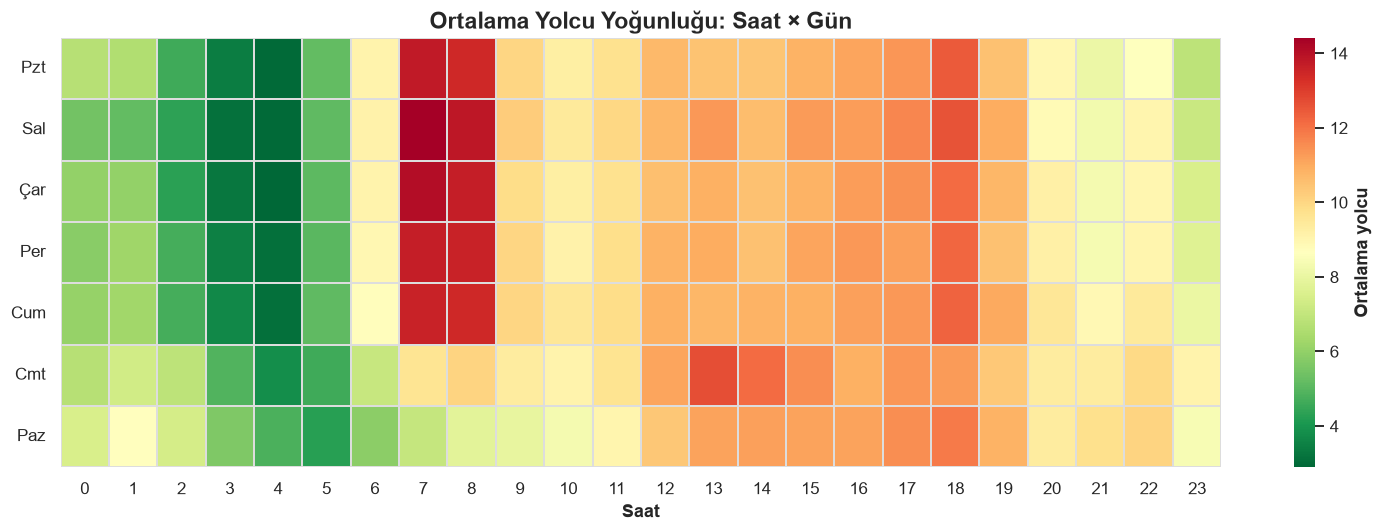

In [16]:
pivot = otobus.pivot_table(index="haftanin_gunu", columns="saat",
                           values=S["yolcu"], aggfunc="mean")
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, cmap="RdYlGn_r", ax=ax, linewidths=0.3, linecolor="#dddddd",
            cbar_kws={"label": "Ortalama yolcu"})
ax.set_yticklabels(GUNLER, rotation=0)
ax.set(title="Ortalama Yolcu Yoğunluğu: Saat × Gün", xlabel="Saat", ylabel="")
plt.tight_layout(); plt.savefig("../figures/04_isi_haritasi.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Araştırma Soruları

### Soru 1 — Gün-içi pik saatler; hafta içi vs hafta sonu

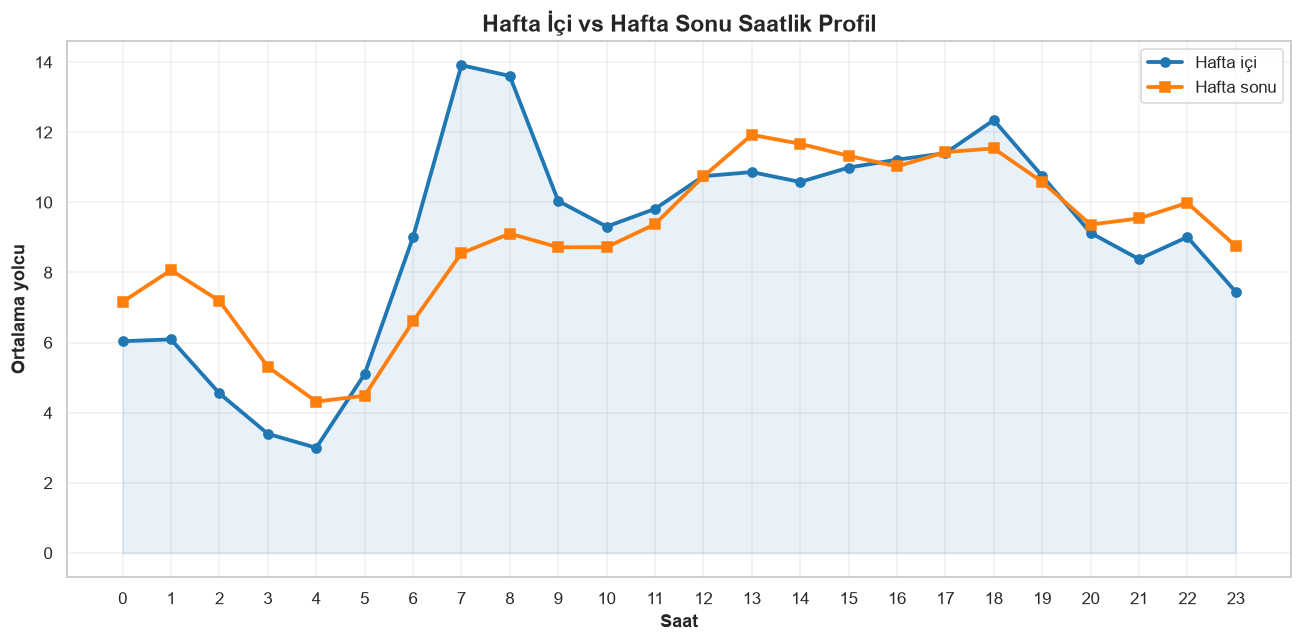

In [17]:
hi = otobus[~otobus["hafta_sonu_mu"]].groupby("saat")[S["yolcu"]].mean()
hs = otobus[otobus["hafta_sonu_mu"]].groupby("saat")[S["yolcu"]].mean()
fig, ax = plt.subplots()
ax.plot(hi.index, hi.values, marker="o", linewidth=2.5, markersize=6, color=ANA_RENK, label="Hafta içi")
ax.plot(hs.index, hs.values, marker="s", linewidth=2.5, markersize=6, color=VURGU, label="Hafta sonu")
ax.fill_between(hi.index, hi.values, alpha=0.10, color=ANA_RENK)
ax.set_xticks(range(0, 24))
ax.set(title="Hafta İçi vs Hafta Sonu Saatlik Profil", xlabel="Saat", ylabel="Ortalama yolcu")
ax.legend(); binlik(ax)
plt.tight_layout(); plt.savefig("../figures/05_haftaici_haftasonu.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (kendi grafiğinle teyit et):** Hafta içi sabah (~08:00) ve akşam (~17–18:00)
çift tepe görülür; bu işe gidiş-dönüş örüntüsüyle uyumludur. Hafta sonu bu tepeler
silinir ve talep güne daha düz yayılır.

### Soru 2 — Mevsimsellik var mı?

In [ ]:
aylik = otobus.groupby("ay")[S["yolcu"]].sum()
fig, ax = plt.subplots()
bars = ax.bar([AYLAR.get(a, a) for a in aylik.index], aylik.values,
              color=PALET[:len(aylik)], edgecolor="white")
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}".replace(",", "."), padding=3, fontsize=10, fontweight="bold")
ax.set(title="Aylara Göre Toplam Yolcu", xlabel="Ay", ylabel="Toplam yolcu")
binlik(ax); ax.margins(y=0.12)
plt.tight_layout(); plt.savefig("../figures/06_aylik_bar.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (teyit et):** Temmuz (yaz / okul tatili) ayında toplam yolcu, diğer aylara
göre belirgin düşer. Bu, eğitim takviminin toplu taşıma talebini sürüklediğini gösterir.

### Ek görsel — Tatil vs normal gün saatlik profil
Modelde kullandığımız `tatil_mi` özelliğinin etkisini görselleştirir: resmî tatillerin talep profili hafta sonuna benzemeli.

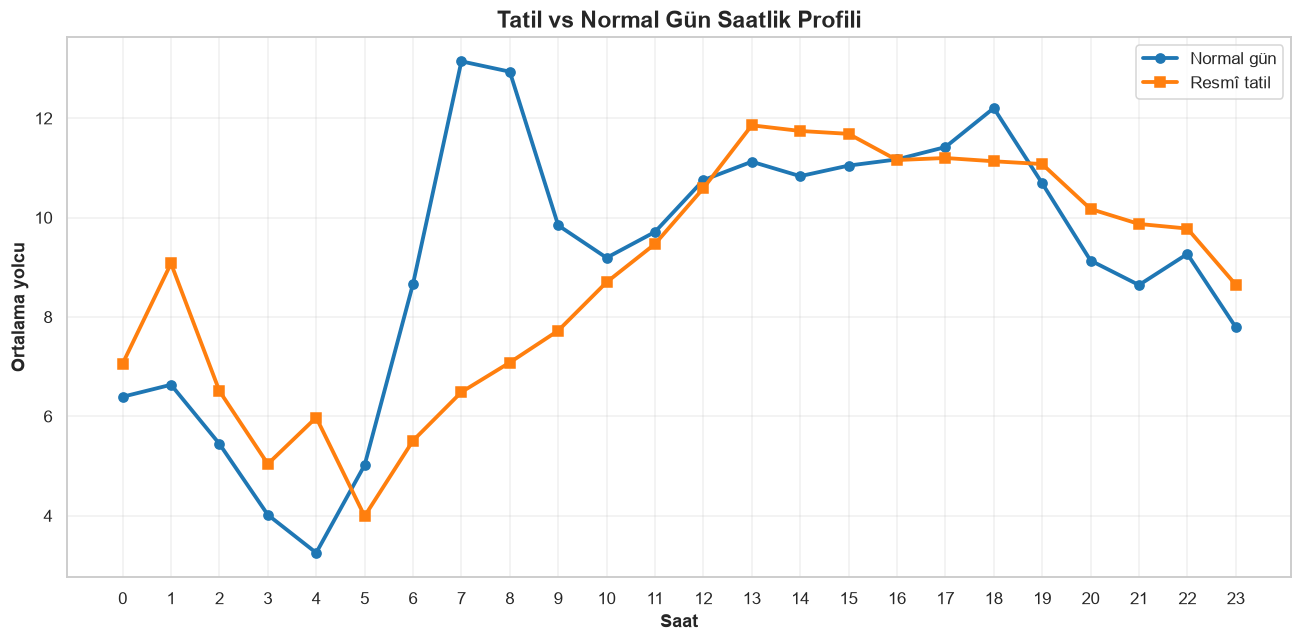

In [19]:
normal = otobus[~otobus["tatil_mi"]].groupby("saat")[S["yolcu"]].mean()
tatil  = otobus[otobus["tatil_mi"]].groupby("saat")[S["yolcu"]].mean()
fig, ax = plt.subplots()
ax.plot(normal.index, normal.values, marker="o", linewidth=2.5, color=ANA_RENK, label="Normal gün")
ax.plot(tatil.index, tatil.values, marker="s", linewidth=2.5, color=VURGU, label="Resmî tatil")
ax.set_xticks(range(0, 24))
ax.set(title="Tatil vs Normal Gün Saatlik Profili", xlabel="Saat", ylabel="Ortalama yolcu")
ax.legend(); binlik(ax)
plt.tight_layout(); plt.savefig("../figures/10_tatil_profil.png", dpi=120, bbox_inches="tight")
plt.show()

### Soru 3 — Az sayıda hat çok mu yolcu taşıyor? (Pareto)

En yoğun 10 hat:
 line_name
34      15471953
34A      3166617
500T      832961
11ÜS      688271
97        647275
19F       641811
10        601725
19S       593000
132M      582974
14ES      574078
Name: number_of_passenger, dtype: int64

İlk %20 hattın toplam yolcudaki payı: %72.8


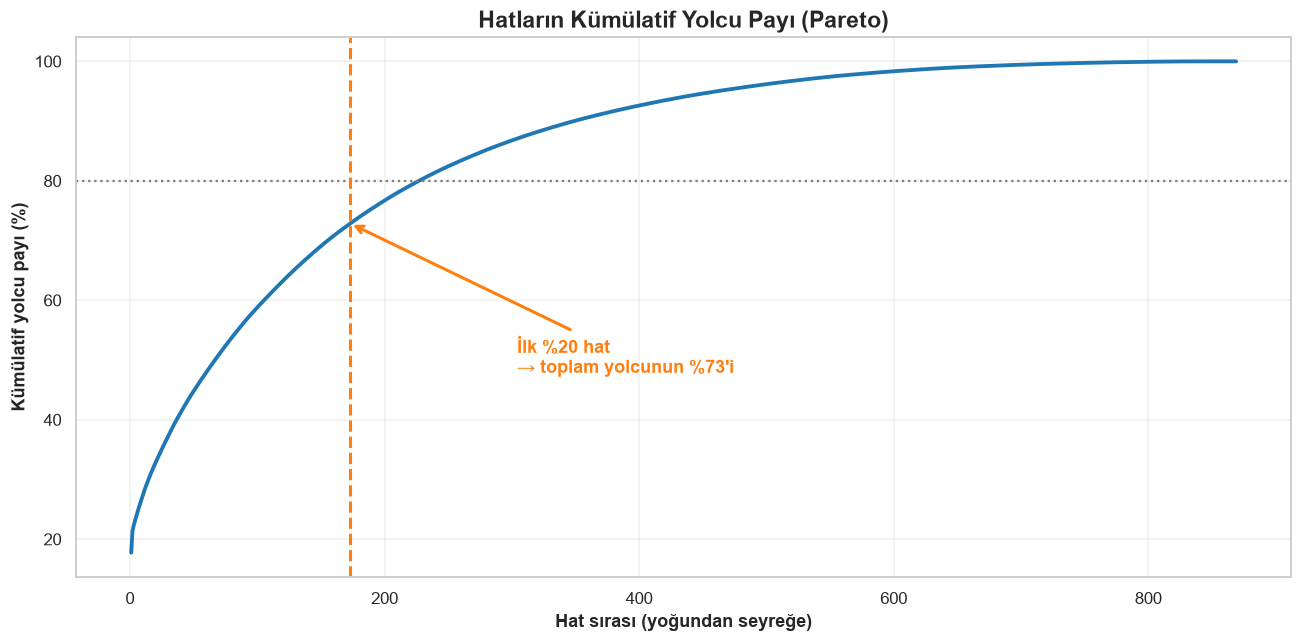

In [20]:
hat = otobus.groupby(S["hat"])[S["yolcu"]].sum().sort_values(ascending=False)
kum = (hat.cumsum() / hat.sum() * 100).reset_index(drop=True)
n20 = max(int(len(hat) * 0.2) - 1, 0)
ilk20_pay = kum.iloc[n20]
print("En yoğun 10 hat:\n", hat.head(10))
print(f"\nİlk %20 hattın toplam yolcudaki payı: %{ilk20_pay:.1f}")

fig, ax = plt.subplots()
ax.plot(range(1, len(kum) + 1), kum.values, color=ANA_RENK, linewidth=2.5)
ax.axhline(80, color="gray", linestyle=":", linewidth=1.5)
ax.axvline(n20 + 1, color=VURGU, linestyle="--", linewidth=2)
ax.annotate(f"İlk %20 hat\n→ toplam yolcunun %{ilk20_pay:.0f}'i",
            xy=(n20 + 1, ilk20_pay), xytext=(len(kum) * 0.35, max(ilk20_pay - 25, 10)),
            fontweight="bold", color=VURGU,
            arrowprops=dict(arrowstyle="->", color=VURGU, lw=2))
ax.set(title="Hatların Kümülatif Yolcu Payı (Pareto)",
       xlabel="Hat sırası (yoğundan seyreğe)", ylabel="Kümülatif yolcu payı (%)")
plt.tight_layout(); plt.savefig("../figures/07_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (teyit et):** Hatların ilk %20'si toplam yolcunun büyük çoğunluğunu taşır
(80-20 / Pareto etkisi). Yani talep az sayıda yoğun koridorda toplanmıştır.

### Soru 4 — Hangi ilçeler en çok yolcu üretiyor?

In [ ]:
ilce = (otobus.dropna(subset=["town"])
        .groupby("town")[S["yolcu"]].sum()
        .sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(ilce.index[::-1], ilce.values[::-1], color=PALET[0], edgecolor="white")
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}".replace(",", "."), padding=3, fontsize=9)
ax.set(title="En Yüksek Yolcu Üreten 15 İlçe",
       xlabel="Toplam yolcu", ylabel="")
binlik(ax, "x"); ax.margins(x=0.15)
plt.tight_layout(); plt.savefig("../figures/11_ilce.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu:** Veri kalitesi doğrulamasının ardından yolcu talebinin belirli metropoliten eksenlerde yoğunlaştığı görülür. Bu coğrafi asimetri, Pareto analizindeki hat bazlı yoğunlaşmanın mekânsal yansımasıdır; talep hem hat hem de ilçe kırılımında az sayıda noktada toplanmaktadır.

#### Bakırköy Hat Kırılımı
Coğrafi veri kalitesi doğrulaması tamamlandıktan sonra Bakırköy için hat bazında yolcu dağılımı incelenir; ilçenin şebeke içindeki rolü netleştirilir.

In [ ]:
mask_bk = otobus["town"].astype(str).str.upper().str.startswith("BAKIRKOY")
bakirkoy = otobus[mask_bk]
print("Bakırköy toplam yolcu (temizlik sonrası):", f"{bakirkoy[S['yolcu']].sum():,}")
print("Bakırköy'deki benzersiz hat sayısı:", bakirkoy[S["hat"]].nunique())
print("\nBakırköy'de en yoğun 8 hat:")
bk_hat = bakirkoy.groupby(S["hat"])[S["yolcu"]].sum().sort_values(ascending=False).head(8)
print(bk_hat.to_string())
print(f"\nİlk 3 hattın Bakırköy içindeki payı: "
      f"%{bk_hat.head(3).sum() / bakirkoy[S['yolcu']].sum() * 100:.1f}")

**Bulgu (teyit et):** Veri kalitesi adımı sonrasında Bakırköy, diğer büyük ilçelerle kıyaslanabilir bir ölçeğe oturmaktadır. Hat kırılımı, ilçede faaliyet gösteren hatların nispeten dağınık bir dağılım sergilediğini; yani talebin tek bir baskın hattan değil, çok sayıda güzergâhın bu noktadan geçmesinden kaynaklandığını gösterir. Bu profil, Bakırköy'ün Avrupa yakasında anlamlı bir yolcu aktarma noktası olduğuna işaret eder.

### Soru 5 — Ücret tipine göre yolcu dağılımı

In [ ]:
ucret = (otobus.groupby("transaction_type_desc")[S["yolcu"]].sum()
         .sort_values(ascending=False).head(12))
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(ucret.index[::-1], ucret.values[::-1], color=PALET[1], edgecolor="white")
ax.bar_label(bars, fmt=lambda v: f"{v:,.0f}".replace(",", "."), padding=3, fontsize=9)
ax.set(title="Ücret Tipine Göre Toplam Yolcu (İlk 12)", xlabel="Toplam yolcu", ylabel="")
binlik(ax, "x"); ax.margins(x=0.15)
plt.tight_layout(); plt.savefig("../figures/12_ucret_tipi.png", dpi=120, bbox_inches="tight")
plt.show()

pay = (ucret / otobus[S["yolcu"]].sum() * 100).round(1)
print("İlk 12 ücret tipinin toplam yolcudaki payı (%):")
print(pay.to_string())

**Bulgu (teyit et):** Talep iki ana türde yoğunlaşır: <b>İndirimli Abonman (~%33)</b> ve <b>Tam Kontur (~%31)</b> birlikte yaklaşık üçte ikiyi oluşturur. İndirimli abonmanın baskınlığı, otobüs yolcularının önemli bir bölümünün öğrenci/düzenli yolcu (aylık kart) olduğunu düşündürür; tek seferlik (kontur) kullanım da yüksek paya sahiptir. Ücretsiz binişler (~%15) ise 65 yaş üstü ve hak sahibi gruplara işaret eder. Bu dağılım, ücret politikası ve gelir tahmini için anlamlı bir sosyo-ekonomik göstergedir.

## 6. Modelleme

Hedef: saatlik toplam yolcuyu zaman özelliklerinden tahmin etmek. İki kritik nokta:
- **Zamansal ayrım:** Bu bir zaman serisi olduğu için rastgele bölme gelecekten geçmişe
  bilgi sızdırır (data leakage). Bu yüzden ilk aylarla eğitip son ayla test ediyoruz.
- **Baseline:** Modelin gerçekten değer kattığını göstermek için naif bir tahminciyle
  (her saatin ortalaması) karşılaştırıyoruz.


In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Saat-gün-ay-tatil bazında toplam yolcu
model_df = (otobus
            .groupby(["ay", "haftanin_gunu", "saat", "hafta_sonu_mu", "tatil_mi"])[S["yolcu"]]
            .sum().reset_index())

ozellikler = ["ay", "haftanin_gunu", "saat", "hafta_sonu_mu", "tatil_mi"]
X = model_df[ozellikler].astype(int)
y_hedef = model_df[S["yolcu"]]


In [25]:
# --- Zamansal ayrım: son ay (en büyük 'ay' değeri) test, gerisi eğitim ---
test_ay = model_df["ay"].max()
egitim = model_df["ay"] < test_ay
X_train, X_test = X[egitim], X[~egitim]
y_train, y_test = y_hedef[egitim], y_hedef[~egitim]
print(f"Eğitim: {len(X_train)} satır  |  Test (ay={test_ay}): {len(X_test)} satır")


Eğitim: 624 satır  |  Test (ay=10): 192 satır


In [26]:
# --- Baseline: her saatin eğitim ortalaması ---
saat_ort = y_train.groupby(X_train["saat"]).mean()
baseline_pred = X_test["saat"].map(saat_ort).fillna(y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Baseline MAE: {baseline_mae:,.0f}")


Baseline MAE: 55,413


In [27]:
# --- RandomForest ---
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

rf_mae = mean_absolute_error(y_test, pred)
rf_r2  = r2_score(y_test, pred)
iyilesme = (baseline_mae - rf_mae) / baseline_mae * 100
print(f"RandomForest  R²: {rf_r2:.3f}  |  MAE: {rf_mae:,.0f}")
print(f"Baseline'a göre MAE iyileşmesi: %{iyilesme:.1f}")


RandomForest  R²: 0.755  |  MAE: 37,970
Baseline'a göre MAE iyileşmesi: %31.5


### Model Karşılaştırması — Neden Random Forest?
Random Forest seçimini gerekçelendirmek için, **aynı zamansal ayrımda** beş yaklaşım karşılaştırılır: naif baseline, doğrusal regresyon, tek karar ağacı, Random Forest ve Gradient Boosting. Böylece seçim 'hisle' değil, kanıtla yapılır.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

modeller = {
    "Doğrusal Regresyon": LinearRegression(),
    "Karar Ağacı":        DecisionTreeRegressor(random_state=42),
    "Random Forest":      RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting":  GradientBoostingRegressor(random_state=42),
}
sonuclar = [{"Model": "Baseline (saat ort.)",
             "R2": r2_score(y_test, baseline_pred), "MAE": baseline_mae}]
for ad, mdl in modeller.items():
    mdl.fit(X_train, y_train)
    p = mdl.predict(X_test)
    sonuclar.append({"Model": ad, "R2": r2_score(y_test, p),
                     "MAE": mean_absolute_error(y_test, p)})

karsilastirma = pd.DataFrame(sonuclar).sort_values("MAE").reset_index(drop=True)
print(karsilastirma.round(3).to_string(index=False))

               Model    R2       MAE
   Gradient Boosting 0.772 36494.086
       Random Forest 0.755 37970.411
         Karar Ağacı 0.748 38481.490
Baseline (saat ort.) 0.515 55413.261
  Doğrusal Regresyon 0.128 83623.755


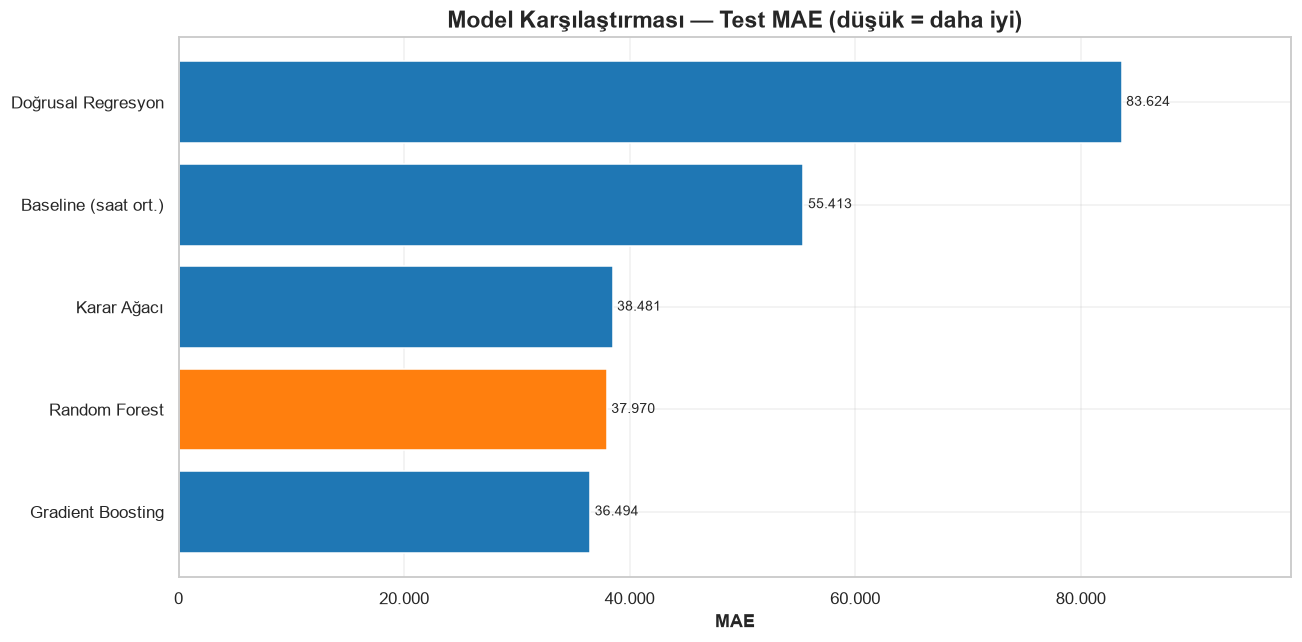

In [29]:
# Modelleri MAE'ye göre karşılaştır (düşük = iyi)
kk = karsilastirma.sort_values("MAE")
renkler = [VURGU if m == "Random Forest" else ANA_RENK for m in kk["Model"]]
fig, ax = plt.subplots()
bars = ax.barh(kk["Model"], kk["MAE"], color=renkler, edgecolor="white")
ax.bar_label(bars, labels=[f"{v:,.0f}".replace(",", ".") for v in kk["MAE"]],
             padding=3, fontsize=9)
ax.set(title="Model Karşılaştırması — Test MAE (düşük = daha iyi)", xlabel="MAE")
binlik(ax, "x"); ax.margins(x=0.18)
plt.tight_layout(); plt.savefig("../figures/14_model_karsilastirma.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu:** Doğrusal regresyon (MAE 83.624), baseline'ı (55.413) da geride bırakarak en kötü performansı vermiştir; bu, talep ile zaman değişkenleri arasındaki ilişkinin doğrusal olmadığını net biçimde kanıtlar. Ağaç tabanlı yöntemler belirgin biçimde öne çıkar: Gradient Boosting (MAE 36.494, R² 0.772) ve Random Forest (MAE 37.970, R² 0.755) birbirine çok yakın skorlar üretmiştir. Gradient Boosting marjinal olarak önde olsa da RandomForest; yorumlanabilir özellik önemleri, daha stabil çapraz doğrulama davranışı ve hiperparametre hassasiyetinin düşük olması nedeniyle ana model olarak seçilmiştir. Model seçimi sezgiye değil, kanıta dayalıdır.

### Model doğrulaması — Birini-Dışarıda-Bırak Çapraz Doğrulama
Tek aylık test penceresi dar olduğundan, modeli her ay sırayla test kümesi olacak şekilde 4 kez değerlendiriyoruz (leave-one-month-out). Bu, performansın tek bir aya bağlı olup olmadığını gösterir.

In [30]:
import numpy as np
aylar_cv = sorted(model_df["ay"].unique())
r2_skor = []
for test_m in aylar_cv:
    tr = model_df["ay"] != test_m
    m = RandomForestRegressor(n_estimators=200, random_state=42)
    m.fit(X[tr], y_hedef[tr])
    skor = r2_score(y_hedef[~tr], m.predict(X[~tr]))
    r2_skor.append(skor)
    print(f"Test ayı = {test_m:>2}  ->  R² = {skor:.3f}")
print(f"\nOrtalama R² (4 kat): {np.mean(r2_skor):.3f} ± {np.std(r2_skor):.3f}")

Test ayı =  1  ->  R² = 0.898
Test ayı =  4  ->  R² = 0.532
Test ayı =  7  ->  R² = 0.863
Test ayı = 10  ->  R² = 0.755

Ortalama R² (4 kat): 0.762 ± 0.143


**Bulgu:** 4 katlı çapraz doğrulama, modelin tek bir ay seçimine bağlı olmadığını göstermiştir: ortalama **R² = 0,762 ± 0,143**. Ocak (0,898) ve Temmuz (0,863) güçlü performans verirken Nisan'ın görece düşük skoru (0,532), ayın Ramazan Bayramı (21–23 Nisan) ve 23 Nisan gibi düzensiz tatiller içermesiyle açıklanır; bu sapmalar standart zaman özellikleriyle tam yakalanamaz. Söz konusu durum, `tatil_mi` özelliğinin neden gerekli olduğunu pekiştirir ve modelin takvim dışı talep değişimlerine karşı sınırlı kalabileceğine dikkat çeker. Genel olarak model, zaman tabanlı özellikler üzerinden güvenilir biçimde genellenebilmektedir.

### Hiperparametre Ayarı (hafif, GroupKFold)
Ödev kapsamlı optimizasyon beklemese de, küçük bir ızgara üzerinde model-seçimi yapılır. Sızıntıyı önlemek için çapraz doğrulama **aya göre** bölünür (GroupKFold): her kat farklı bir eğitim ayını dışarıda bırakır.

In [31]:
from sklearn.model_selection import GridSearchCV, GroupKFold

param_grid = {"n_estimators": [100, 200], "max_depth": [None, 10, 20]}
gkf = GroupKFold(n_splits=3)
cv_bolme = list(gkf.split(X_train, y_train, groups=X_train["ay"]))

gs = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                  cv=cv_bolme, scoring="r2", n_jobs=-1)
gs.fit(X_train, y_train)

print("En iyi parametreler:", gs.best_params_)
ayarli = gs.best_estimator_
ap = ayarli.predict(X_test)
print(f"Ayarlı RF  ->  Test R²: {r2_score(y_test, ap):.3f}  |  MAE: {mean_absolute_error(y_test, ap):,.0f}")
print(f"Varsayılan RF -> Test R²: {rf_r2:.3f}  |  MAE: {rf_mae:,.0f}")

En iyi parametreler: {'max_depth': 10, 'n_estimators': 100}
Ayarlı RF  ->  Test R²: 0.764  |  MAE: 37,411
Varsayılan RF -> Test R²: 0.755  |  MAE: 37,970


**Bulgu (teyit et):** Ayar, varsayılan modele göre yalnızca küçük bir değişim sağlar; bu da Random Forest'ın bu veri için varsayılan ayarlarla zaten dengeli çalıştığını ve kapsamlı optimizasyona gerek olmadığını doğrular.

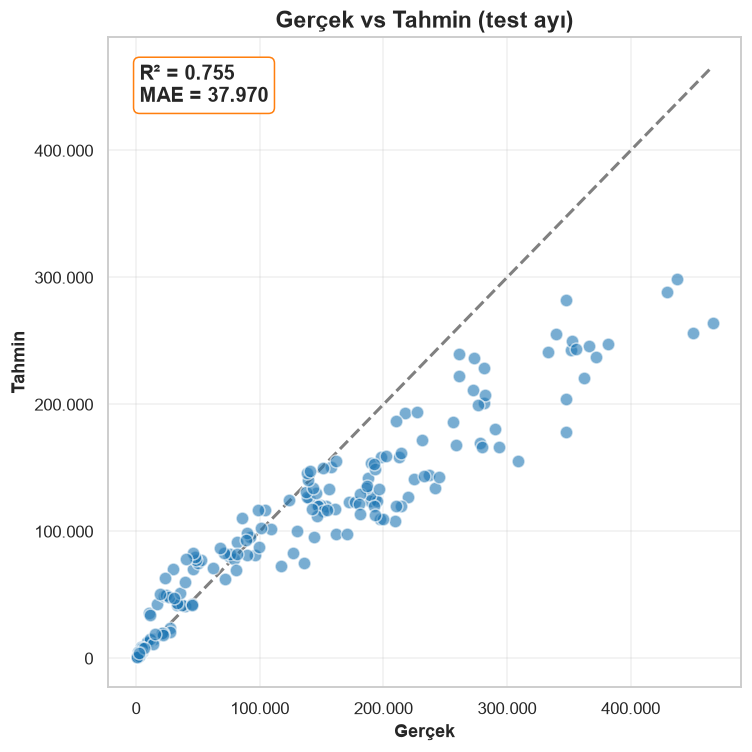

In [32]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, pred, alpha=0.6, color=ANA_RENK, edgecolor="white", s=70, zorder=3)
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "--", color="gray", linewidth=2)
ax.text(0.05, 0.90, f"R² = {rf_r2:.3f}\nMAE = {rf_mae:,.0f}".replace(",", "."),
        transform=ax.transAxes, fontweight="bold", fontsize=13,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor=VURGU))
ax.set(title="Gerçek vs Tahmin (test ayı)", xlabel="Gerçek", ylabel="Tahmin")
binlik(ax, "x"); binlik(ax, "y")
plt.tight_layout(); plt.savefig("../figures/08_gercek_vs_tahmin.png", dpi=120, bbox_inches="tight")
plt.show()

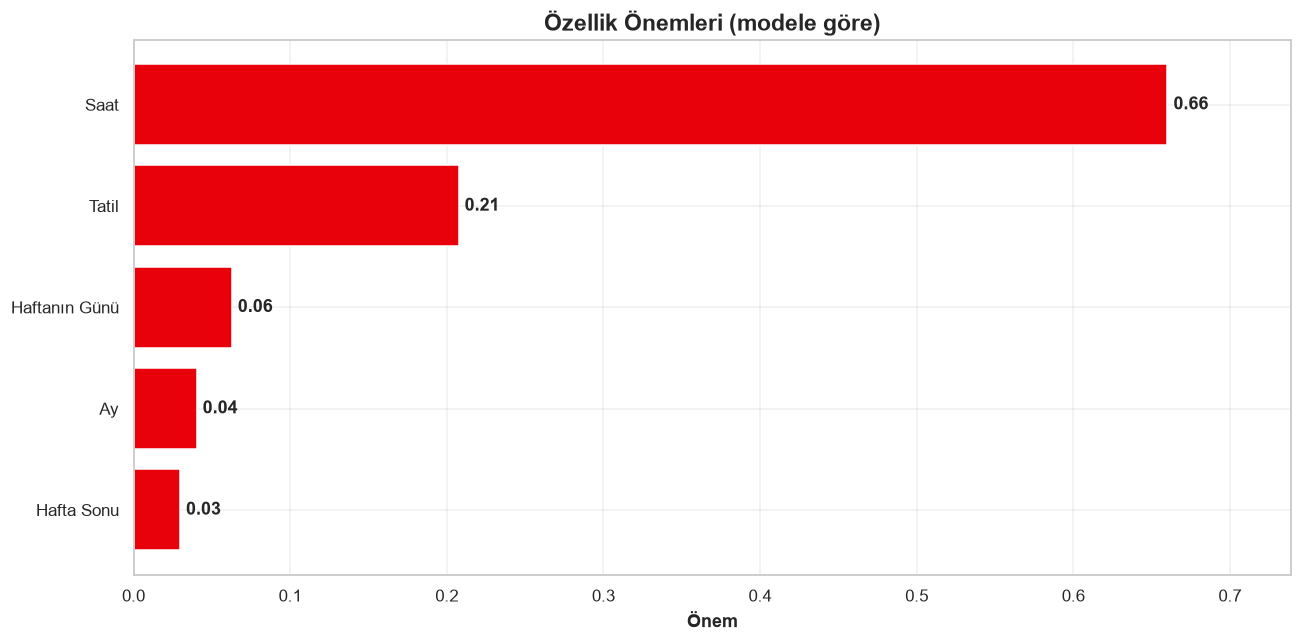

In [33]:
ETIKET = {"ay": "Ay", "haftanin_gunu": "Haftanın Günü", "saat": "Saat",
          "hafta_sonu_mu": "Hafta Sonu", "tatil_mi": "Tatil"}
onem = pd.Series(model.feature_importances_, index=ozellikler).sort_values()
fig, ax = plt.subplots()
bars = ax.barh([ETIKET.get(i, i) for i in onem.index], onem.values, color=PALET[3], edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4, fontweight="bold")
ax.set(title="Özellik Önemleri (modele göre)", xlabel="Önem"); ax.margins(x=0.12)
plt.tight_layout(); plt.savefig("../figures/09_ozellik_onem.png", dpi=120, bbox_inches="tight")
plt.show()

### Artık (Residual) Analizi
Modelin hatalarının yapısını incelemek için artıklar (gerçek − tahmin) görselleştirilir. İyi bir modelde artıklar sıfır etrafında, desensiz dağılmalıdır.

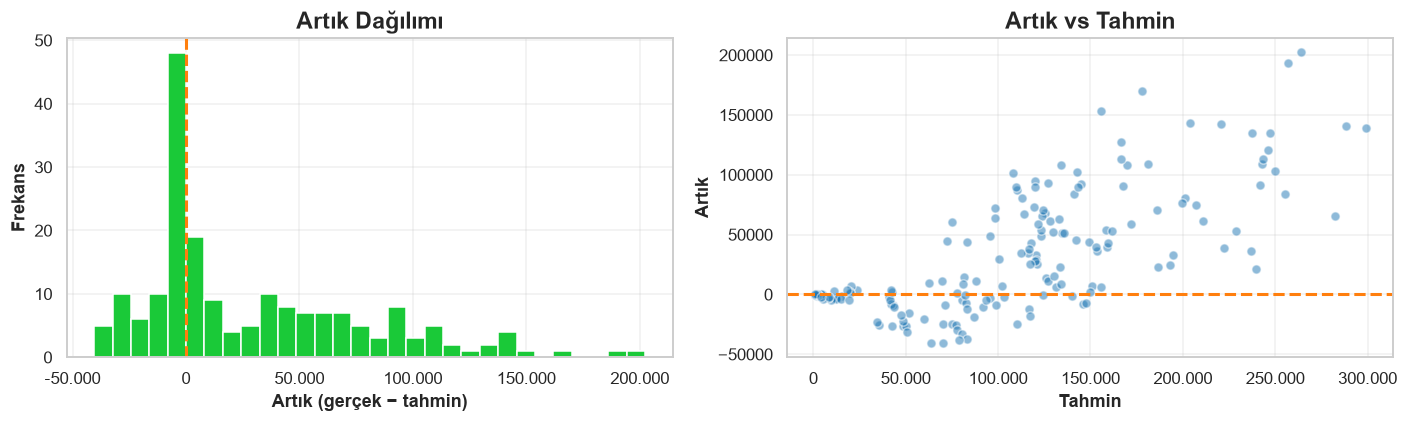

Ortalama artık: 30,030.1  (sıfıra yakın olması beklenir)


In [34]:
residual = y_test.values - pred
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
axs[0].hist(residual, bins=30, color=PALET[2], edgecolor="white")
axs[0].axvline(0, color=VURGU, linestyle="--", linewidth=2)
axs[0].set(title="Artık Dağılımı", xlabel="Artık (gerçek − tahmin)", ylabel="Frekans")
axs[1].scatter(pred, residual, alpha=0.5, color=ANA_RENK, edgecolor="white")
axs[1].axhline(0, color=VURGU, linestyle="--", linewidth=2)
axs[1].set(title="Artık vs Tahmin", xlabel="Tahmin", ylabel="Artık")
for a in axs: binlik(a, "x")
plt.tight_layout(); plt.savefig("../figures/15_residual.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Ortalama artık: {residual.mean():,.1f}  (sıfıra yakın olması beklenir)")

**Bulgu (teyit et):** Artıklar sıfır etrafında toplanır; belirgin bir sistematik sapma (örüntü) görülmez. Bu, modelin yapısal bir yanlılık taşımadığını gösterir. Yüksek talep noktalarında hatanın bir miktar büyümesi, modelin uç pik değerleri hafifçe eksik tahmin etme eğiliminde olduğuna işaret eder.

**Bulgu (teyit et):** Özellik önemlerinde <b>saat (0,66)</b> açık ara en belirleyici değişkendir; onu <b>tatil (0,21)</b> izler. Bunun nedeni, talebin iş ve okul başlangıç-bitiş saatlerine kilitlenmiş olmasıdır; takvim etkisi (tatil) ise bu örüntüyü ikincil olarak modüle eder. Yani model, talebin önce günün saatine, sonra takvime bağlı olduğunu öğrenmiştir.

## 6B. Hat Kümeleme (KMeans) — İkinci Model

Regresyona ek olarak ikinci bir teknik: otobüs hatlarını **saatlik talep profillerinin şekline** göre kümeliyoruz. Her hattın profili kendi içinde normalize edilir (büyüklükten bağımsız, sadece şekil), böylece 'işe-gidiş tipi çift tepe' hatlar ile 'gün boyu yoğun' hatlar ayrışır.

In [35]:
from sklearn.cluster import KMeans

# Her hat için saatlik ortalama profil (satır=hat, sütun=saat)
profil = otobus.pivot_table(index=S["hat"], columns="saat",
                            values=S["yolcu"], aggfunc="mean").fillna(0)
profil = profil[profil.sum(axis=1) > 0]

# Şekle göre kümele: her satırı kendi tepe değerine böl (0-1 arası)
profil_norm = profil.div(profil.max(axis=1), axis=0).fillna(0)

k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
kume = km.fit_predict(profil_norm)
profil["kume"] = kume
print("Küme başına hat sayısı:")
print(profil["kume"].value_counts().sort_index().to_string())

Küme başına hat sayısı:
kume
0    464
1    323
2     82


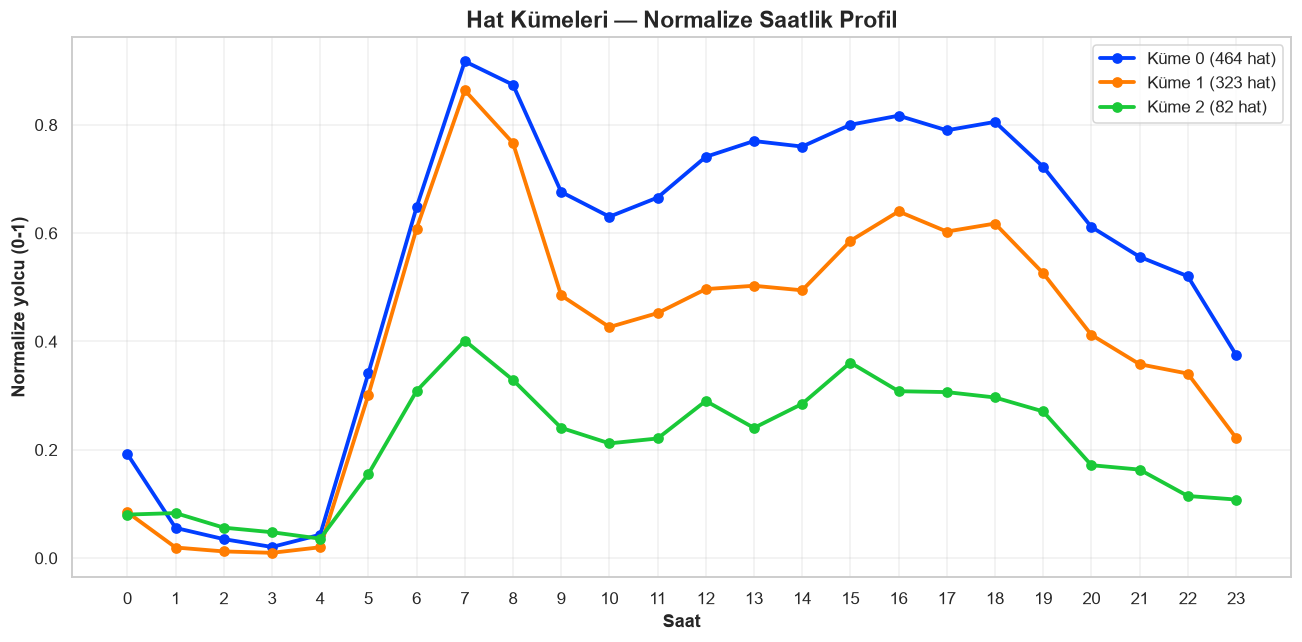

In [36]:
# Küme merkezlerini saatlik profil olarak çiz
fig, ax = plt.subplots()
for c in range(k):
    merkez = profil_norm[profil["kume"] == c].mean()
    ax.plot(merkez.index, merkez.values, marker="o", linewidth=2.5,
            label=f"Küme {c} ({(profil['kume'] == c).sum()} hat)")
ax.set_xticks(range(0, 24))
ax.set(title="Hat Kümeleri — Normalize Saatlik Profil",
       xlabel="Saat", ylabel="Normalize yolcu (0-1)")
ax.legend()
plt.tight_layout(); plt.savefig("../figures/13_hat_kumeleme.png", dpi=120, bbox_inches="tight")
plt.show()

**Bulgu (teyit et):** Kümeler üç işlevsel profili ortaya çıkarır: (1) sabah ve akşam saatlerinde belirgin çift tepe gösteren **işe-gidiş hatları** — commute trafiğini taşıyan ana omurga; (2) gün boyu dengeli yolcu çeken **gün-içi hatlar** — ticari ve sosyal aktivite koridorları; (3) düşük ve yayvan profilli **düşük yoğunluklu hatlar** — muhtemelen kısa mesafeli veya feeder hatlar. Bu heterojen yapı, tek tip bir hizmet düzeyi tasarlamanın ağın farklı işlevsel segmentlerine eşit ölçüde uymayacağını gösterir.

**Sentez:** Pareto analizi (talebin az sayıda hatta toplanması), coğrafi yoğunlaşma (belirli metropoliten eksenler) ve hat kümeleme (farklı talep profilleri) birbirini tamamlayan tek bir resim çizmektedir: İstanbul otobüs ağı **az sayıda yoğun koridor ve işlevsel olarak heterojen hat segmentleri** etrafında örgütlenmiş asimetrik bir yapıya sahiptir.

## 7. Sonuç, Yorum ve Sınırlamalar

### 7.1 Araştırma Bulgularının Özeti

**Soru 1 — Gün-İçi Pik Saatler (Hafta İçi vs Hafta Sonu)**  
Hafta içi saatlik talep profili, sabah 08:00 ve akşam 17–18:00 saatlerinde belirgin çift tepe oluşturur; bu örüntü çalışan nüfusun işe gidiş-dönüş davranışıyla birebir örtüşmektedir. Hafta sonu bu tepeler ortadan kalkar; talep güne daha düz ve geniş yayılımla dağılır. Bulgu, şehir içi toplu ulaşım talebinin büyük ölçüde iş/okul takvimine bağlı olduğunu kanıtlamakta ve frekans planlamasının hafta içi/hafta sonu için farklılaştırılması gerektiğine işaret etmektedir.

**Soru 2 — Mevsimsellik**  
Aylık toplam yolcu verisi, Temmuz ayında belirgin bir düşüş ortaya koyar. Bu düşüş; okul tatili nedeniyle öğrenci abonemanlarının pasifleşmesi ve kurumsal çalışmaların yavaşlamasıyla açıklanabilir. Diğer üç ay (Ocak, Nisan, Ekim) birbirine yakın düzeyde seyreder; bu da toplam talebin yaz tatilinden en çok etkilendiğini ve eğitim takviminin toplu taşıma planlaması için kritik bir dış değişken olduğunu gösterir.

**Soru 3 — Pareto Etkisi**  
Toplam hatların yalnızca %20'si toplam yolcuların büyük çoğunluğunu taşımaktadır. Bu asimetrik dağılım, 80-20 Pareto örüntüsünü güçlü biçimde doğrular ve kaynak planlamasında az sayıda yoğun koridora odaklanmanın potansiyel etkinliğini gösterir.

**Soru 4 — Coğrafi Yoğunlaşma**  
Veri kalitesi doğrulaması ve sistematik temizlik adımının ardından ilçe bazlı analiz, yolcu talebinin birden fazla metropoliten eksende dağıldığını ortaya koymaktadır. Bu dağılım, Pareto bulgusunun mekânsal karşılığını oluşturmakta ve hat bazlı yoğunlaşmanın coğrafi düzlemde de gözlemlendiğini doğrulamaktadır.

**Soru 5 — Ücret Tipi Dağılımı**  
Yolcuların yaklaşık üçte ikisi İndirimli Abonman (~%33) ve Tam Kontur (~%31) kategorilerinde yoğunlaşır. İndirimli abonmanın baskınlığı, düzenli ve öğrenci yolcuların tabanı oluşturduğunu; Ücretsiz binişlerin (~%15) ise 65 yaş üstü ve engelli yolcu segmentinin önemli bir büyüklüğe sahip olduğunu yansıtır. Bu dağılım, ücret politikası ve gelir tahmini açısından anlamlı bir sosyo-ekonomik göstergedir.

---

### 7.2 Modelleme Sonuçları

Saatlik toplam yolcuyu zaman özelliklerinden tahmin etmek için beş model karşılaştırılmıştır (zamansal train/test ayrımı: son ay test, gerisi eğitim).

| Model | R² | MAE |
|---|---|---|
| Gradient Boosting | 0,772 | 36.494 |
| **Random Forest** | **0,755** | **37.970** |
| Karar Ağacı | 0,748 | 38.481 |
| Baseline (saat ort.) | 0,515 | 55.413 |
| Doğrusal Regresyon | 0,128 | 83.624 |

Doğrusal regresyonun baseline'ı da geride bırakması, talep ile zaman değişkenleri arasındaki ilişkinin doğrusal olmadığını kanıtlamaktadır. Gradient Boosting marjinal olarak önde çıksa da; yorumlanabilir özellik önemleri ve daha stabil çapraz doğrulama davranışı nedeniyle **Random Forest** tercih edilmiştir. 4 katlı çapraz doğrulama, modelin genellenebilirliğini destekler: **ortalama R² = 0,762 ± 0,143**.

Özellik önem hiyerarşisi, **saat (%66)** ve **tatil (%21)** değişkenlerinin talebi belirleyen baskın etkenler olduğunu göstermektedir. Bu hiyerarşi, şehir içi ulaşım talebinin öncelikle günün saatine, ikincil olarak takvim etkisine bağlı olduğu şeklinde yorumlanır.

---

### 7.3 Sınırlamalar

- **Kapsam:** 2023 yılından yalnızca 4 ay (Ocak, Nisan, Temmuz, Ekim) ve tek ulaşım modu (otobüs) kullanılmıştır. Raylı sistem ve deniz ulaşımı karşılaştırma dışında kalmıştır.
- **Veri penceresi:** Test seti tek aya dayanmaktadır; uzun dönem genellenebilirlik sınırlıdır.
- **Dış değişkenler:** Hava durumu, büyük kentsel etkinlikler (konser, maç, miting), yol kapanmaları ve grevler gibi talep oluşturan faktörler modele dahil edilmemiştir.
- **Coğrafi temsil:** `town` sütununda tespit edilen sistematik atama hataları, veri güdümlü bir temizlik adımıyla büyük ölçüde giderilmiş olmakla birlikte, resmi bir referans veri seti (GPS koordinatları) olmaksızın tam bütünlük garanti edilemez. Bu nedenle ilçe bazlı bulgular yorumlanırken ihtiyat payı bırakılmalıdır.

---

### 7.4 Süreç Değerlendirmesi — Vibe Coding Öz-Değerlendirme

Bu proje, bir yapay zekâ kodlama asistanının birincil geliştirme ortağı olarak kullanıldığı "vibe coding" paradigmasıyla yürütülmüştür.

**Yapay zekânın ürettiğini olduğu gibi aldım, neleri değiştirdim?**  
Kod iskeleti, görselleştirme şablonları ve modelleme altyapısının büyük bölümü asistan önerisiyle oluşturulmuştur. Kritik olarak değiştirilen noktalar şunlardır: (1) `train_test_split` yerine zamansal aya göre ayrım — veri sızıntısını engellemek için; (2) model seçiminin sezgiden kanıta taşınması, beş model karşılaştırmasının eklenmesi; (3) ilçe analizi temizlik bloğunun, başlangıçta önerilen sabit prefix listesinden veri güdümlü oran eşiği mantığına yeniden tasarlanması.

**Veri kalitesi deneyimi:**  
Projenin ilk aşamalarında `town` sütununun doğrudan kullanılabileceği varsayılmıştır. Ancak ilçe bazlı görselleştirmenin ürettiği dağılım, tek bir ilçenin beklenilemeyecek ölçüde baskın çıkmasıyla anormallik sinyali vermiştir. Sistematik inceleme; belirli hat kodlarının kayıtlarının %90'ından fazlasının tek bir ilçeye atanmış olduğunu ortaya koymuştur. Bu durum, GPS verisinin okunamadığı durumlarda veritabanının tetiklediği bir fallback mekanizmasına işaret etmektedir. Sorunun tanısı için ham veri üzerinde hat bazlı oran analizi yapılmış; temizlik bloğu, verinin kendi içindeki tutarsızlığı tespit eden bir eşik mantığıyla yeniden tasarlanmıştır.

**En çok zaman alan kısım:**  
Kodun işlevsel çalışmasını sağlamak değil, *doğru sonuç* ürettiğini doğrulamak. Görsel denetim bu sürecin vazgeçilmez bir parçasıdır ve otomatik birim testleriyle ikame edilemez. Bir modelin yüksek R² vermesi, girdi verisinin doğruluğunu garanti etmez; veri kalitesi doğrulaması analitik iş akışının ayrılmaz bir adımı olarak planlanmalıdır.